In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))
from paths import *


# Pool by species


## Setup


In [ ]:
# web_data_final.zip -> one folder per species, shuffled, 1.png..N.png,
# plus a dictionary saying what each number was.
# 5 models x 2 conditions x 10 images = 100 per species.

import csv, glob, hashlib, json, os, random, shutil, zipfile
from collections import Counter, defaultdict
from pathlib import Path

DRIVE = str(ROOT)
ZIP   = f"{DRIVE}/web_data_final.zip"    

EXTRACT = "/content/web_data_final"
POOLED  = f"{DRIVE}/pooled"

SEED = 42

print("zip:", ZIP, "-", "found" if os.path.exists(ZIP) else "MISSING")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
zip: /content/drive/MyDrive/Synthetic_Plants_Project/web_data_final.zip - found


## Extract


In [ ]:
# the zip may or may not have a wrapper dir search for base/ and
# lora/ 
if not os.path.exists(ZIP):
    raise SystemExit(f"no archive at {ZIP} -- check the filename")

if os.path.exists(EXTRACT):
    shutil.rmtree(EXTRACT)
os.makedirs(EXTRACT)

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
    print(f"{len(names)} entries in the archive")
    z.extractall(EXTRACT)

def find_root(top):
    for dirpath, dirnames, _ in os.walk(top):
        if "base" in dirnames and "lora" in dirnames:
            return dirpath
    return None

WEB = find_root(EXTRACT)

if WEB is None:
    print("\ncould not find a directory containing both base/ and lora/.")
    print("Top two levels of what was extracted:\n")
    for dirpath, dirnames, filenames in os.walk(EXTRACT):
        depth = dirpath[len(EXTRACT):].count(os.sep)
        if depth > 2:
            dirnames[:] = []
            continue
        print("  " * depth + (os.path.basename(dirpath) or "."),
              f"({len(filenames)} files)")
    raise SystemExit("set WEB by hand to the right path and continue")

print("\nusing:", WEB)
for cond in sorted(os.listdir(WEB)):
    d = os.path.join(WEB, cond)
    if os.path.isdir(d):
        subs = [x for x in sorted(os.listdir(d))
                if os.path.isdir(os.path.join(d, x))]
        n = len(glob.glob(os.path.join(d, "*", "*.png")))
        print(f"  {cond:<18} {len(subs):>3} folders, {n:>4} images")


342 entries in the archive

using: /content/web_data_final/web_data
  base                15 folders,  150 images
  lora                15 folders,  150 images
  structure_first      3 folders,    3 images


## Folder names


In [ ]:
# species is spelled three ways across the tree (carprobrotus in the model
# folders, cbrotus in the structure-first ones). normalise on read inconsistencies do not affect dictionary 
# To Do: Standardise if time Permits
SPECIES_ALIASES = {
    "achillea":     "achillea",
    "eryngium":     "eryngium",
    "carpobrotus":  "carpobrotus",
    "carprobrotus": "carpobrotus",   
    "cbrotus":      "carpobrotus",   
}

MODEL_ALIASES = {
    "sdxl": "sdxl", "pixart": "pixart", "qwen": "qwen",
    "flux": "flux", "flux2": "flux",
    "sf": "structure_first",
}

EXCLUDE = ("_control.png", "_flat.png", "_mask.png")

def parse(folder_name):
    """'sdxl_carprobrotus' -> ('sdxl', 'carpobrotus'); None if unrecognised."""
    if "_" not in folder_name:
        return None
    model_raw, species_raw = folder_name.rsplit("_", 1)
    model = MODEL_ALIASES.get(model_raw.lower())
    species = SPECIES_ALIASES.get(species_raw.lower())
    if model is None or species is None:
        return None
    return model, species

def scan():
    """[(condition, model, species, [files])] across the whole tree."""
    found, unparsed = [], []
    for cond in ("base", "lora"):
        root = os.path.join(WEB, cond)
        if not os.path.isdir(root):
            continue
        for name in sorted(os.listdir(root)):
            d = os.path.join(root, name)
            if not os.path.isdir(d):
                continue
            parsed = parse(name)
            if parsed is None:
                unparsed.append(f"{cond}/{name}")
                continue
            model, species = parsed
            files = [f for f in sorted(glob.glob(os.path.join(d, "*.png")))
                     if not f.endswith(EXCLUDE)]
            found.append((cond, model, species, files))
    return found, unparsed

found, unparsed = scan()

print(f"{'folder':<34} {'condition':<10} {'model':<18} {'species':<14} {'n':>4}")
print("-" * 86)
for cond, model, species, files in found:
    print(f"{cond + '/' + model + '_' + species:<34} {cond:<10} "
          f"{model:<18} {species:<14} {len(files):>4}")

if unparsed:
    print(f"\n{len(unparsed)} folder(s) not recognised:")
    for u in unparsed:
        print("   ", u)
    print("Add the spelling to SPECIES_ALIASES or MODEL_ALIASES above.")


folder                             condition  model              species           n
--------------------------------------------------------------------------------------
base/flux_achillea                 base       flux               achillea         10
base/flux_carpobrotus              base       flux               carpobrotus      10
base/flux_eryngium                 base       flux               eryngium         10
base/pixart_achillea               base       pixart             achillea         10
base/pixart_carpobrotus            base       pixart             carpobrotus      10
base/pixart_eryngium               base       pixart             eryngium         10
base/qwen_achillea                 base       qwen               achillea         10
base/qwen_carpobrotus              base       qwen               carpobrotus      10
base/qwen_eryngium                 base       qwen               eryngium         10
base/sdxl_achillea                 base       sdxl             

## Check the counts


In [ ]:
# a model present in one condition and missing from the other silently
# unbalances the comparison
by_species = defaultdict(list)
for cond, model, species, files in found:
    by_species[species].append((cond, model, files))

for species in sorted(by_species):
    entries = by_species[species]
    total = sum(len(f) for _, _, f in entries)
    print(f"\n{species}: {total} images from {len(entries)} folders")
    counts = Counter()
    for cond, model, files in entries:
        counts[(model, cond)] = len(files)
    models = sorted({m for m, _ in counts})
    print(f"  {'model':<18} {'base':>6} {'lora':>6}")
    for m in models:
        b, l = counts.get((m, "base"), 0), counts.get((m, "lora"), 0)
        flag = "   <-- unbalanced" if b != l else ""
        print(f"  {m:<18} {b:>6} {l:>6}{flag}")



achillea  —  100 images from 10 folders
  model                base   lora
  flux                   10     10
  pixart                 10     10
  qwen                   10     10
  sdxl                   10     10
  structure_first        10     10

carpobrotus  —  100 images from 10 folders
  model                base   lora
  flux                   10     10
  pixart                 10     10
  qwen                   10     10
  sdxl                   10     10
  structure_first        10     10

eryngium  —  100 images from 10 folders
  model                base   lora
  flux                   10     10
  pixart                 10     10
  qwen                   10     10
  sdxl                   10     10
  structure_first        10     10


## Pool and number


In [ ]:
# shuffle seeded per species so adding one later doesn't reorder the rest
# A plain shuffle regularly leaves runs of eight or ten identical conditions,
# which is the thing interleaving is meant to prevent: a rater who sees ten
# baselines in a row recalibrates, and everything after it shifts. This walks through
# the sequence and, wherever a run exceeds MAX_RUN, swaps in the nearest later
# item of a different condition. 

MAX_RUN = 3

def break_runs(items, max_run, rng):
    out = list(items)
    i, run, prev = 0, 0, None
    while i < len(out):
        cond = out[i]["condition"]
        run = run + 1 if cond == prev else 1
        if run > max_run:
            swap = next((j for j in range(i + 1, len(out))
                         if out[j]["condition"] != cond), None)
            if swap is None:
                break            
            out[i], out[swap] = out[swap], out[i]
            run = 1
        prev = out[i]["condition"]
        i += 1
    return out


In [9]:
FORCE = False        # True to overwrite an existing pooled tree

dictionary = []
summary = {}

for species in sorted(by_species):
    dest = Path(POOLED) / species
    if dest.exists() and any(dest.glob("*.png")) and not FORCE:
        print(f"{species}: already populated, skipping (set FORCE = True)")
        continue

    # collect every image with its provenance attached
    items = []
    for cond, model, files in by_species[species]:
        for f in files:
            items.append({"source": f, "model": model, "condition": cond})

    rng = random.Random(f"{SEED}:{species}")
    rng.shuffle(items)
    items = break_runs(items, MAX_RUN, rng)

    if dest.exists():
        shutil.rmtree(dest)
    dest.mkdir(parents=True)

    for i, it in enumerate(items, start=1):
        shutil.copy(it["source"], dest / f"{i}.png")
        dictionary.append({
            "species": species,
            "index": i,
            "filename": f"{i}.png",
            "pooled_path": f"{species}/{i}.png",
            "model": it["model"],
            "condition": it["condition"],
            "lora": it["condition"] == "lora",
            "source": it["source"],
            "md5": hashlib.md5(open(it["source"], "rb").read()).hexdigest(),
        })

    summary[species] = len(items)
    print(f"{species:<14} {len(items):>4} images -> {dest}")

print(f"\ntotal {sum(summary.values())} images")


achillea        100 images -> /content/drive/MyDrive/Synthetic_Plants_Project/pooled/achillea
carpobrotus     100 images -> /content/drive/MyDrive/Synthetic_Plants_Project/pooled/carpobrotus
eryngium        100 images -> /content/drive/MyDrive/Synthetic_Plants_Project/pooled/eryngium

total 300 images


## Dictionary


In [10]:
# json for code, csv to sit next to the exported ratings in a spreadsheet
os.makedirs(POOLED, exist_ok=True)

payload = {
    "seed": SEED,
    "counts": summary,
    "note": ("index is the filename shown to raters; model and condition are "
             "what it actually was. Conditions are interleaved, so index "
             "carries no information about the condition."),
    "images": dictionary,
}

jpath = Path(POOLED) / "dictionary.json"
jpath.write_text(json.dumps(payload, indent=2))

cpath = Path(POOLED) / "dictionary.csv"
with open(cpath, "w", newline="") as fh:
    cols = ["species", "index", "filename", "model", "condition", "lora",
            "source", "md5"]
    w = csv.DictWriter(fh, fieldnames=cols, extrasaction="ignore")
    w.writeheader()
    w.writerows(dictionary)

print(f"{len(dictionary)} rows")
print(" ", jpath)
print(" ", cpath)


300 rows
  /content/drive/MyDrive/Synthetic_Plants_Project/pooled/dictionary.json
  /content/drive/MyDrive/Synthetic_Plants_Project/pooled/dictionary.csv


## Verify


In [11]:
# counts are what we expect, and the shuffle actually interleaved rather
# than leaving runs of one condition
# counts per model and condition, recovered from the dictionary
for species in sorted(summary):
    rows = [d for d in dictionary if d["species"] == species]
    counts = Counter((d["model"], d["condition"]) for d in rows)
    models = sorted({m for m, _ in counts})
    print(f"\n{species}  ({len(rows)} images)")
    print(f"  {'model':<18} {'base':>6} {'lora':>6}")
    for m in models:
        print(f"  {m:<18} {counts.get((m, 'base'), 0):>6} "
              f"{counts.get((m, 'lora'), 0):>6}")



achillea  (100 images)
  model                base   lora
  flux                   10     10
  pixart                 10     10
  qwen                   10     10
  sdxl                   10     10
  structure_first        10     10

carpobrotus  (100 images)
  model                base   lora
  flux                   10     10
  pixart                 10     10
  qwen                   10     10
  sdxl                   10     10
  structure_first        10     10

eryngium  (100 images)
  model                base   lora
  flux                   10     10
  pixart                 10     10
  qwen                   10     10
  sdxl                   10     10
  structure_first        10     10


In [12]:
# longest run of the same condition; a long run means the shuffle failed
for species in sorted(summary):
    seq = [d["condition"] for d in
           sorted((x for x in dictionary if x["species"] == species),
                  key=lambda x: x["index"])]
    longest, run = 0, 0
    prev = None
    for s in seq:
        run = run + 1 if s == prev else 1
        longest = max(longest, run)
        prev = s
    print(f"{species:<14} longest run of one condition: {longest}")
    print(f"  first 20: {' '.join('L' if s == 'lora' else 'b' for s in seq[:20])}")


achillea       longest run of one condition: 3
  first 20: L L b L L L b b L b b L L L b b b L b b
carpobrotus    longest run of one condition: 3
  first 20: L L b L b b L b b b L b b b L b L L b b
eryngium       longest run of one condition: 3
  first 20: L L L b L L L b L L b b L L b L b L L b


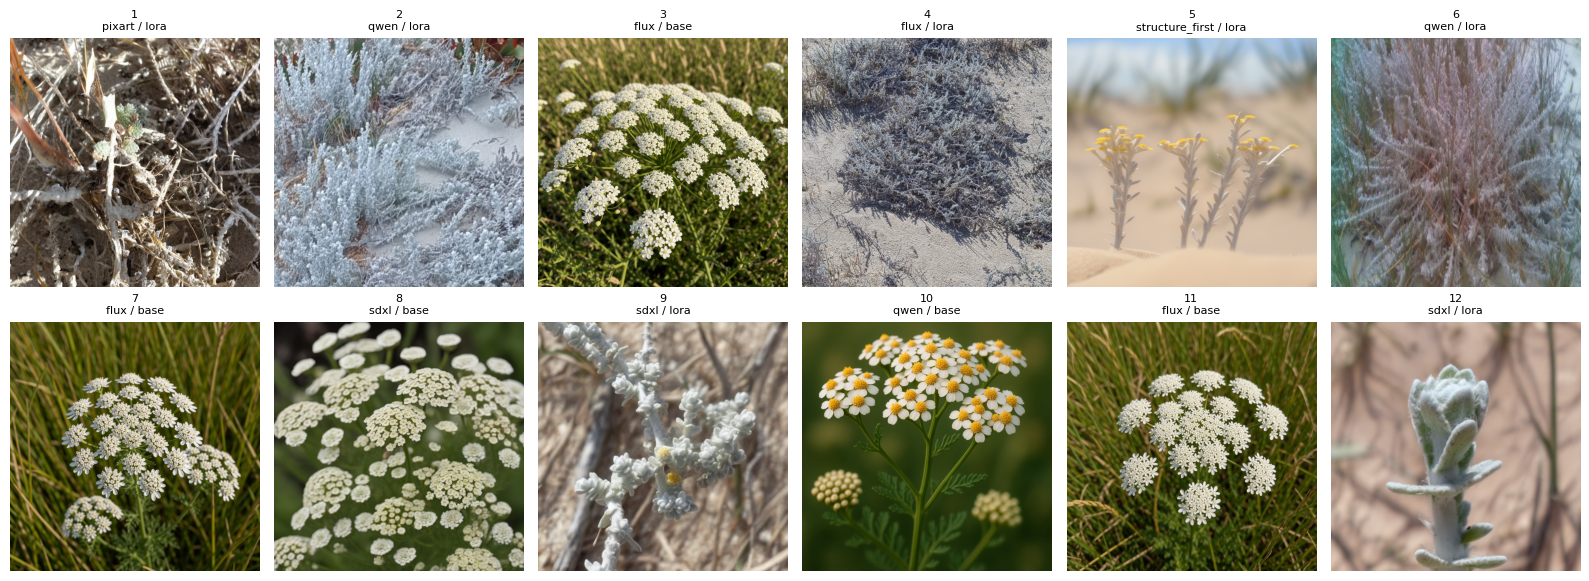

In [ ]:

import matplotlib.pyplot as plt
from PIL import Image

SHOW = "achillea"
rows = sorted((d for d in dictionary if d["species"] == SHOW),
              key=lambda x: x["index"])[:12]

if rows:
    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    for ax, d in zip(axes.ravel(), rows):
        ax.axis("off")
        f = Path(POOLED) / d["pooled_path"]
        if f.exists():
            ax.imshow(Image.open(f).convert("RGB"))
        ax.set_title(f"{d['index']}\n{d['model']} / {d['condition']}",
                     fontsize=8)
    for ax in axes.ravel()[len(rows):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("nothing pooled for", SHOW)


## Zip


In [ ]:

shutil.make_archive("/content/pooled", "zip", POOLED)
print(f"/content/pooled.zip  ({os.path.getsize('/content/pooled.zip') / 1e6:.0f} MB)")

from google.colab import files
files.download("/content/pooled.zip")


/content/pooled.zip  (494 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>